In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import StandardScaler, OneHotEncoder, PolynomialFeatures
from sklearn.compose import make_column_transformer, ColumnTransformer
from sklearn.metrics import ConfusionMatrixDisplay, confusion_matrix
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.preprocessing import OneHotEncoder, PolynomialFeatures
from sklearn.ensemble import RandomForestRegressor
from sklearn.datasets import fetch_openml
from sklearn.pipeline import Pipeline


In [ ]:
#pull airline fuel data tables from BTS website
url = "https://www.transtats.bts.gov/fuel.asp?20=E"
tables = pd.read_html(url)

#check how many tables were scraped from webpage
print(len(tables))

6


In [ ]:
#save csv
tables[4].to_csv("fuel_data.csv", index=False)

In [ ]:
"""

from fredapi import Fred

fred = Fred(api_key='a1bff20e1c4adc5270296a6d2c342e84')

oil = fred.get_series('DCOILWTICO')

gdp = fred.get_series('GDP')

inflation = fred.get_series('CPIAUCSL')

"""

"\n\nfrom fredapi import Fred\n\nfred = Fred(api_key='a1bff20e1c4adc5270296a6d2c342e84')\n\noil = fred.get_series('DCOILWTICO')\n\ngdp = fred.get_series('GDP')\n\ninflation = fred.get_series('CPIAUCSL')\n\n"

In [ ]:
#load macroeconomic data
gdp = pd.read_csv("GDP.csv")
inflation = pd.read_csv("CPIAUCSL.csv")
oil = pd.read_csv("DCOILWTICO.csv")

In [ ]:
#load airline data
passengers = pd.read_html("Passengers_5_8_2026 6_31_56 PM.xls")[0]

lf = pd.read_html("LoadFactor_5_8_2026 6_32_19 PM.xls")[0]
lf = pd.DataFrame(lf)

fuel = pd.read_csv("fuel_data.csv")

delay = pd.read_csv("Airline_Delay_Cause.csv")

profit = pd.read_html("Operating_PL_5_8_2026 5_56_35 PM.xls")[0]

In [ ]:
#clean profit data,keep only year, quarter, total profit
profit['Year'] = pd.to_numeric(profit['Year'], errors='coerce')

profit['Quarter'] = pd.to_numeric(profit['Quarter'], errors='coerce')

profit = profit.dropna(subset=['Quarter'])

profit['Quarter'] = profit['Quarter'].astype(int)

In [ ]:
profit = profit[['Year', 'Quarter', 'TOTAL']]
profit.columns = ['Year', 'Quarter', 'Total_Profit']

In [ ]:
#convert passenger data from monthly to quarterly
passengers['Month'] = pd.to_numeric(passengers['Month'], errors='coerce')

passengers = passengers.dropna(subset=['Month'])

passengers['Month'] = passengers['Month'].astype(int)

passengers['Quarter'] = (passengers['Month'] - 1) // 3 + 1

In [ ]:
passengers = passengers.groupby(['Year', 'Quarter']).sum('Total')
passengers.reset_index(inplace=True)
passengers = passengers[['Year', 'Quarter', 'TOTAL']]
passengers.columns = ['Year', 'Quarter', 'Total_Passengers']

In [ ]:
#convert load factor data from monthly to quarterly
lf['Year'] = pd.to_numeric(lf['Year'], errors='coerce')

lf['Month'] = pd.to_numeric(lf['Month'], errors='coerce')

lf = lf.dropna(subset=['Month'])

lf['Month'] = lf['Month'].astype(int)

lf['Quarter'] = (lf['Month'] - 1) // 3 + 1

In [ ]:
lf = lf.groupby(['Year', 'Quarter']).sum('Total')
lf.reset_index(inplace=True)
lf = lf[['Year', 'Quarter', 'TOTAL']]
lf.columns = ['Year', 'Quarter', 'Total_Load_Factor']

In [ ]:
#rename fuel columns
unique_cols = [
    'Year', 'Month',
    'Domestic_Consumption', 'Domestic_Cost', 'Domestic_Cost_Per_Gallon',
    'International_Consumption', 'International_Cost', 'International_Cost_Per_Gallon',
    'Total_Consumption', 'Total_Cost', 'Total_Cost_Per_Gallon'
]

fuel.columns = unique_cols
#remove blank rows
fuel = fuel.iloc[5:].reset_index(drop=True)
#convert month names to month numbers
month_map = {
    'January': 1, 'February': 2, 'March': 3, 'April': 4,
    'May': 5, 'June': 6, 'July': 7, 'August': 8,
    'September': 9, 'October': 10, 'November': 11, 'December': 12
}
fuel = fuel[fuel['Month'].isin(month_map.keys())].copy()

fuel['Month'] = fuel['Month'].map(month_map)
#create quarter variable from month
fuel['Quarter'] = (fuel['Month'] - 1) // 3 + 1
#convert all fuel columns to numeric
for col in fuel.columns:
    fuel[col] = pd.to_numeric(fuel[col], errors='coerce')

fuel[['Year', 'Month', 'Quarter']] = fuel[['Year', 'Month', 'Quarter']].astype(int)
#move quarter column closer to year and month
cols = list(fuel.columns)
cols.insert(2, cols.pop(cols.index('Quarter')))
fuel = fuel[cols]

In [ ]:
#aggregate fuel cost into quarterly totals
fuel = fuel.groupby(['Year', 'Quarter']).sum()
fuel.reset_index(inplace=True)
fuel = fuel[['Year', 'Quarter', 'Total_Cost']]
fuel.columns = ['Year', 'Quarter', 'Total_Fuel_Cost']

In [ ]:
#clean delay data and count delay records by quarter
delay['year'] = pd.to_numeric(delay['year'], errors='coerce')
delay['month'] = pd.to_numeric(delay['month'], errors='coerce')
delay = delay.dropna(subset=['year', 'month'])

delay['Quarter'] = ((delay['month'] - 1) // 3 + 1).astype(int)
delay['Year'] = delay['year'].astype(int)

delay = delay.groupby(['Year', 'Quarter']).size().reset_index(name='Row_Count')

delay.columns = ['Year', 'Quarter', 'Delay']


In [ ]:
#turn year/quarter into time-series index
def prepare_for_ml(df):
    df['Year'] = pd.to_numeric(df['Year'], errors='coerce')
    df['Quarter'] = pd.to_numeric(df['Quarter'], errors='coerce')

    df['Year'] = df['Year'].astype(int)
    df['Quarter'] = df['Quarter'].astype(int)
    #create a quartely period index
    df['period'] = df.apply(lambda x: pd.Period(year=x['Year'], quarter=x['Quarter'], freq='Q'), axis=1)
    #set period as index
    df = df.set_index('period').sort_index()
    #drop original year/quarter columns
    df = df.drop(columns=['Year', 'Quarter'], errors='ignore')

    return df


In [ ]:
#apply function to each dataset
profit = prepare_for_ml(profit)
passengers = prepare_for_ml(passengers)
lf = prepare_for_ml(lf)
fuel = prepare_for_ml(fuel)
delay = prepare_for_ml(delay)

In [ ]:
#convert data into quarterly averages
def process_fred_to_quarterly(df, name):

    date_col = df.columns[0]
    val_col = df.columns[1]
    #date column to datetime format
    df[date_col] = pd.to_datetime(df[date_col])
    df = df.set_index(date_col)
    #make data numeric
    df[val_col] = pd.to_numeric(df[val_col], errors='coerce')
    #resample data into quarterly average values
    q_data = df[val_col].resample('QS').mean()
    q_data.index = q_data.index.to_period('Q')

    return q_data.rename(name)
#prepare gdp and oil as quarterly variables
gdp = process_fred_to_quarterly(gdp, 'GDP_Growth')
oil = process_fred_to_quarterly(oil, 'Oil_Price')
#merge datasets
final_ml_df = pd.concat([profit, passengers, lf, fuel, delay, gdp, oil], axis=1)
final_ml_df = final_ml_df.dropna()

In [ ]:
final_ml_df

,Total_Profit,Total_Passengers,Total_Load_Factor,Total_Fuel_Cost,Delay,GDP_Growth,Oil_Price
2003Q2,129352.0,20811521.0,228.17,3250.9,103.0,11312.766,28.980476
2003Q3,-192823.0,21717750.0,234.15,3538.8,315.0,11566.669,30.221719
2003Q4,-356052.0,20959577.0,220.16,3629.5,318.0,11772.234,31.168387
2004Q1,-391793.0,20190961.0,214.21,4237.9,309.0,11923.447,35.343443
2004Q2,-1972991.0,22647157.0,232.58,4820.7,297.0,12112.815,38.319032
...,...,...,...,...,...,...,...
2024Q3,1349934.0,44083324.0,262.00,12201.6,429.0,29511.664,76.427500
2024Q4,914734.0,41341108.0,252.22,10776.3,433.0,29825.182,70.729032
2025Q1,314931.0,37464887.0,245.55,10726.2,421.0,30042.113,71.783333
2025Q2,2210263.0,43922192.0,257.44,10988.3,430.0,30485.729,64.567258


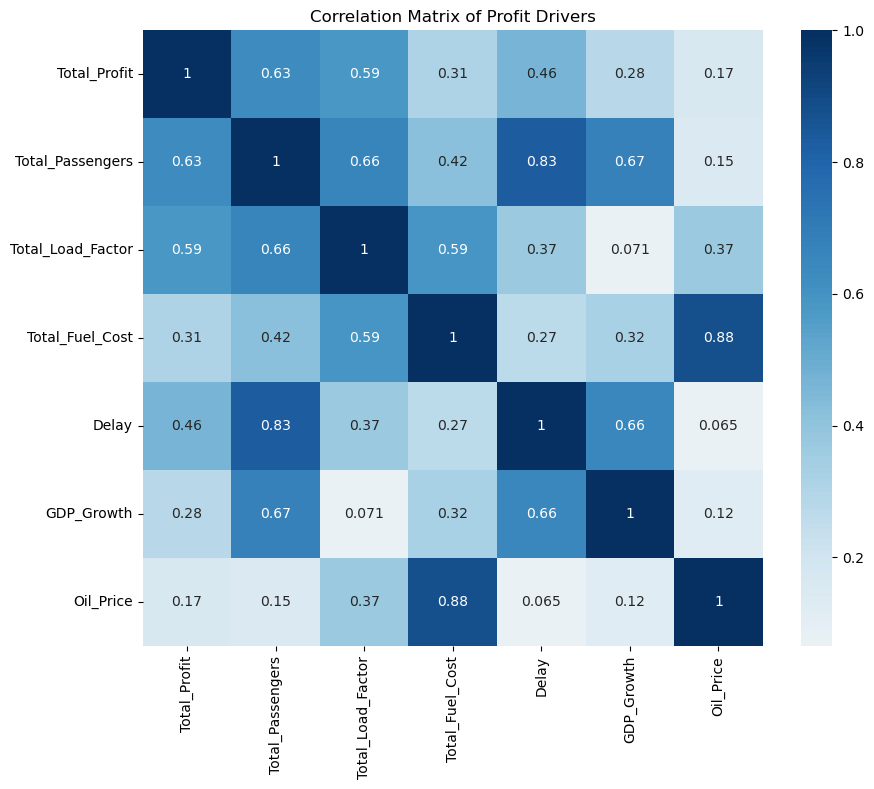

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

#create correlation matrix
corr = final_ml_df.corr()
#plot heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(corr, annot=True, cmap='RdBu', center=0)
plt.title('Correlation Matrix of Profit Drivers')
plt.show()

In [ ]:
import pandas as pd
from sktime.forecasting.model_selection import temporal_train_test_split
from sktime.forecasting.compose import ForecastingPipeline
from sktime.forecasting.compose import make_reduction
from sklearn.ensemble import RandomForestRegressor
from sktime.utils.plotting import plot_series
from sktime.forecasting.model_selection import ForecastingGridSearchCV, SlidingWindowSplitter


In [ ]:
#set target varaible and predictors
y = final_ml_df['Total_Profit']
X = final_ml_df.drop(columns=['Total_Profit'])
#split data by time, using last 8 quarters as test
y_train, y_test, X_train, X_test = temporal_train_test_split(y, X, test_size=8)

In [ ]:
#random forest model
regressor = RandomForestRegressor(n_estimators=100, random_state=42)

forecaster = make_reduction(regressor, window_length=4, strategy="recursive")

forecaster.fit(y=y_train, X=X_train)

RecursiveTabularRegressionForecaster(estimator=RandomForestRegressor(random_state=42),
                                     window_length=4)

(<Figure size 1600x400 with 1 Axes>, <Axes: ylabel='Total_Profit'>)

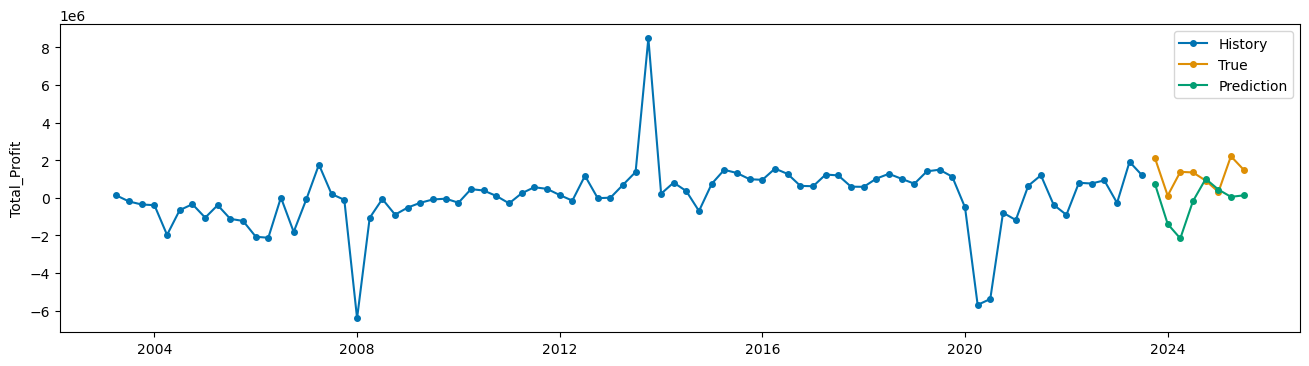

In [ ]:
#predict next 8 quarters
y_pred = forecaster.predict(fh=list(range(1, 9)), X=X_test)
#plot history, true, prediction data
plot_series(y_train, y_test, y_pred, labels=["History", "True", "Prediction"])

In [ ]:
from sktime.performance_metrics.forecasting import MeanAbsolutePercentageError, MeanAbsoluteError
#create another random forest model for tuning
regressor = RandomForestRegressor(random_state=42)
forecaster = make_reduction(regressor, strategy="recursive")
#define parameter combinations to test
param_grid = {
    "window_length": [2, 4, 6, 8],
    "estimator__n_estimators": [50, 100, 200],
    "estimator__max_depth": [None, 5, 10],
    "estimator__min_samples_split": [2, 5]
}
#rolling windows to test forecasting performance over time
cv = SlidingWindowSplitter(initial_window=40, window_length=20, step_length=4)
#mean absolute error as evaluation metric
mae = MeanAbsoluteError()
#grid search
gscv = ForecastingGridSearchCV(
    forecaster,
    strategy="refit",
    cv=cv,
    param_grid=param_grid,
    scoring=mae
)
#fit grid search model on training data
gscv.fit(y=y_train, X=X_train)

print(f"Best Parameters: {gscv.best_params_}")
print(f"Best Score (MAE): {gscv.best_score_}")
#predict using best model
y_pred_best = gscv.predict(fh=list(range(1, 9)), X=X_test)

Best Parameters: {'estimator__max_depth': 5, 'estimator__min_samples_split': 5, 'estimator__n_estimators': 100, 'window_length': 2}
Best Score (MAE): 1567170.8173259916


(<Figure size 1600x400 with 1 Axes>, <Axes: ylabel='Total_Profit'>)

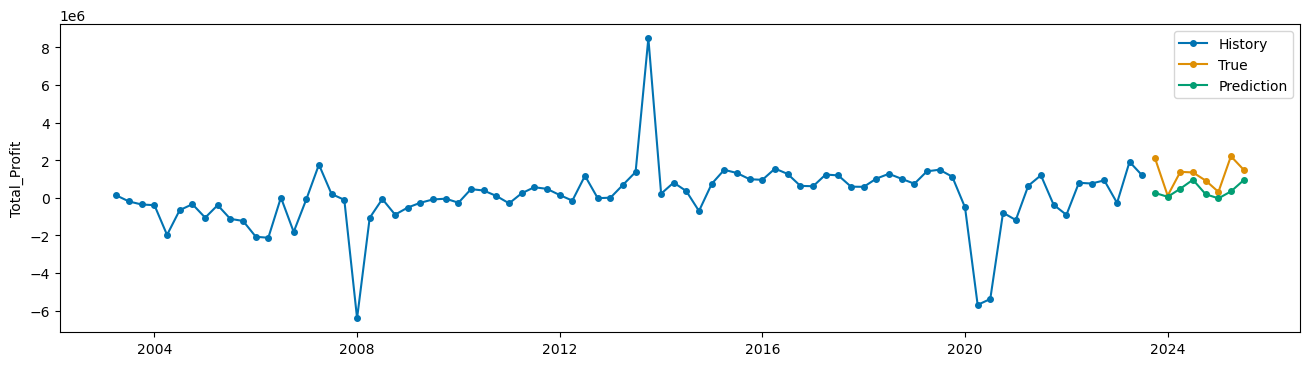

In [ ]:
#plot new prediction results
plot_series(y_train, y_test, y_pred_best, labels=["History", "True", "Prediction"])